#Домашнее задание 1. Реализация модели latent diffusion

##Интро
На семинарах мы познакомились с тем, как обучать диффузионную модель. Эти модели были реализованы через пиксельную диффузию, которую на практике уже никто не использует, потому что это вычислительно сложно обучить. На семинарах было разобрано обучение диффузионной модели. Для обучения вам предлагается обучение модели на датасете `nelorth/oxford-flowers` (https://huggingface.co/datasets/nelorth/oxford-flowers)  

##Цель домашнего задания
Научиться реализовать модель диффузии, модель скрытой диффузии и вносить в нее модификации.

### [5 баллов] Реализация обучения диффузионной модели на новом датасете

В этой части задания вам рекомендуется взять код с семинара и адаптировать его под обучение на новом датасете.

**Ожидаемый результат.** В качестве результатов модели, от вас требуется предоставить визуализации генераций, полученных от вашей модели и код обучения модели.

#### Imports

In [1]:
import os
import math
import random
from inspect import isfunction
from functools import partial

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange
import numpy as np
import torch
from torch import nn, einsum
import torch.nn.functional as F

import torch
from torch.utils.data import Dataset

#### Вспомогательные функции

In [2]:
def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x

def Upsample(dim):
    return nn.ConvTranspose2d(dim, dim, 4, 2, 1)

def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)



#### Позиционные эмбеддинги

In [3]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time) -> torch.Tensor:
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings    

#### Блок ResNet/ConvNeXT

In [4]:
class Block(nn.Module):
    def __init__(self, dim, dim_out, groups = 8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding = 1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift = None):
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x

class ResnetBlock(nn.Module):
    """https://arxiv.org/abs/1512.03385"""

    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out))
            if exists(time_emb_dim)
            else None
        )

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        h = self.block1(x)

        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)
            h = rearrange(time_emb, "b c -> b c 1 1") + h

        h = self.block2(h)
        return h + self.res_conv(x)

class ConvNextBlock(nn.Module):
    """https://arxiv.org/abs/2201.03545"""

    def __init__(self, dim, dim_out, *, time_emb_dim=None, mult=2, norm=True):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.GELU(), nn.Linear(time_emb_dim, dim))
            if exists(time_emb_dim)
            else None
        )

        self.ds_conv = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)

        self.net = nn.Sequential(
            nn.GroupNorm(1, dim) if norm else nn.Identity(),
            nn.Conv2d(dim, dim_out * mult, 3, padding=1),
            nn.GELU(),
            nn.GroupNorm(1, dim_out * mult),
            nn.Conv2d(dim_out * mult, dim_out, 3, padding=1),
        )

        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        h = self.ds_conv(x)

        if exists(self.mlp) and exists(time_emb):
            assert exists(time_emb), "time embedding must be passed in"
            condition = self.mlp(time_emb)
            h = h + rearrange(condition, "b c -> b c 1 1")

        h = self.net(h)
        return h + self.res_conv(x)

#### Attention

Все равно не могу запустить обучение на RTX 3080 10GB. Не хватает памяти.

Будем пробовать scaled_dot_product_attention

In [ ]:
HEADS = 4

# Использует F.scaled_dot_product_attention
class Attention(nn.Module):
    def __init__(self, dim, heads=HEADS, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        print(f"Attention heads: {self.heads} (using memory-efficient scaled_dot_product_attention)")
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        
        # Преобразуем в формат [batch, heads, seq_len, dim_head]
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h (x y) c", h=self.heads), qkv
        )

        # Экономит память на attention matrices
        out = F.scaled_dot_product_attention(q, k, v, scale=self.scale)

        # Преобразуем обратно в пространственный формат
        out = rearrange(out, "b h (x y) c -> b (h c) x y", x=h, y=w)
        return self.to_out(out)


# LinearAttention без изменений
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1),
                                    nn.GroupNorm(1, dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)

#### Групповая нормализация

In [6]:
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)

#### Условная U-Net

- сеть принимает на вход: 
    - батч зашумленных изображений формы `(batch_size, num_channels, height, width)` 
    - и батч уровней шума формы `(batch_size, 1)` 
- и возвращает тензор формы `(batch_size, num_channels, height, width)`


In [7]:
from torch.utils.checkpoint import checkpoint as gradient_checkpoint

class Unet(nn.Module):
    def __init__(
        self,
        dim,
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4, 8),
        channels=3,
        with_time_emb=True,
        resnet_block_groups=8,
        use_convnext=True,
        convnext_mult=2,
        use_gradient_checkpointing=False,  # НОВЫЙ ПАРАМЕТР для экономии памяти
    ):
        super().__init__()

        # определяем размерности
        self.channels = channels
        self.use_gradient_checkpointing = use_gradient_checkpointing

        init_dim = default(init_dim, dim // 3 * 2)
        self.init_conv = nn.Conv2d(channels, init_dim, 7, padding=3)

        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        if use_convnext:
            block_klass = partial(ConvNextBlock, mult=convnext_mult)
        else:
            block_klass = partial(ResnetBlock, groups=resnet_block_groups)

        # time embeddings
        if with_time_emb:
            time_dim = dim * 4
            self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(dim),
                nn.Linear(dim, time_dim),
                nn.GELU(),
                nn.Linear(time_dim, time_dim),
            )
        else:
            time_dim = None
            self.time_mlp = None

        # уровни
        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)

            self.downs.append(
                nn.ModuleList(
                    [
                        block_klass(dim_in, dim_out, time_emb_dim=time_dim),
                        block_klass(dim_out, dim_out, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                        Downsample(dim_out) if not is_last else nn.Identity(),
                    ]
                )
            )

        mid_dim = dims[-1]
        self.mid_block1 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out[1:])):
            is_last = ind >= (num_resolutions - 1)

            self.ups.append(
                nn.ModuleList(
                    [
                        block_klass(dim_out * 2, dim_in, time_emb_dim=time_dim),
                        block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                        Upsample(dim_in) if not is_last else nn.Identity(),
                    ]
                )
            )

        out_dim = default(out_dim, channels)
        self.final_conv = nn.Sequential(
            block_klass(dim, dim), nn.Conv2d(dim, out_dim, 1)
        )

    def forward(self, x, time):
        x = self.init_conv(x)

        t = self.time_mlp(time) if exists(self.time_mlp) else None

        h = []

        # понижение дискретизации (с gradient checkpointing)
        for block1, block2, attn, downsample in self.downs:
            if self.use_gradient_checkpointing and self.training:
                # Используем gradient checkpointing для экономии памяти
                x = gradient_checkpoint(block1, x, t, use_reentrant=False)
                x = gradient_checkpoint(block2, x, t, use_reentrant=False)
                x = gradient_checkpoint(attn, x, use_reentrant=False)
            else:
                x = block1(x, t)
                x = block2(x, t)
                x = attn(x)
            h.append(x)
            x = downsample(x)

        # узкое место (с gradient checkpointing)
        if self.use_gradient_checkpointing and self.training:
            x = gradient_checkpoint(self.mid_block1, x, t, use_reentrant=False)
            x = gradient_checkpoint(self.mid_attn, x, use_reentrant=False)
            x = gradient_checkpoint(self.mid_block2, x, t, use_reentrant=False)
        else:
            x = self.mid_block1(x, t)
            x = self.mid_attn(x)
            x = self.mid_block2(x, t)

        # повышение дискретизации (с gradient checkpointing)
        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            if self.use_gradient_checkpointing and self.training:
                x = gradient_checkpoint(block1, x, t, use_reentrant=False)
                x = gradient_checkpoint(block2, x, t, use_reentrant=False)
                x = gradient_checkpoint(attn, x, use_reentrant=False)
            else:
                x = block1(x, t)
                x = block2(x, t)
                x = attn(x)
            x = upsample(x)

        return self.final_conv(x)

#### Определение процесса прямой диффузии

- косинусный график отклонений

In [8]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    косинусный график как в https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start

##### Прямая диффузия q_sample

In [9]:
# прямая диффузия
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x_start.shape
    )

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

#### Dataset nelorth/oxford-flowers

In [10]:
from datasets import load_dataset

dataset = load_dataset(
    "nelorth/oxford-flowers",
)


In [11]:
# Show dataset information: size, splits, features, etc.
print("Dataset splits:", dataset.keys())
for split in dataset.keys():
    print(f"Split '{split}':")
    print(f"  Number of samples: {len(dataset[split])}")
    print(f"  Number of class labels: {len(dataset[split].features['label'].names)}")
    print(f"  Features: {dataset[split].features}")

# Print the size of the first image in the train split
for i in range(10):
    image = dataset["train"][i]["image"]
    print(f"Image size {i}:", image.size)




Dataset splits: dict_keys(['train', 'test'])
Split 'train':
  Number of samples: 7169
  Number of class labels: 102
  Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['1', '10', '100', '101', '102', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99'])}
Split 'test':
  Number of samples: 1020
  Number of class labels: 102
  Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['1', '10', '100', '101', '102', '11', '12', '1

Вывод: 
- Нам нужно ресайзить изображения до одного размера.
- Возьмем пока меньший размер 256x256.

#### Vars

In [12]:
image_size = 256
channels = 3  # RGB цветные изображения (было 1 для grayscale)
batch_size = 8  # уменьшение для экономии памяти (было 16)

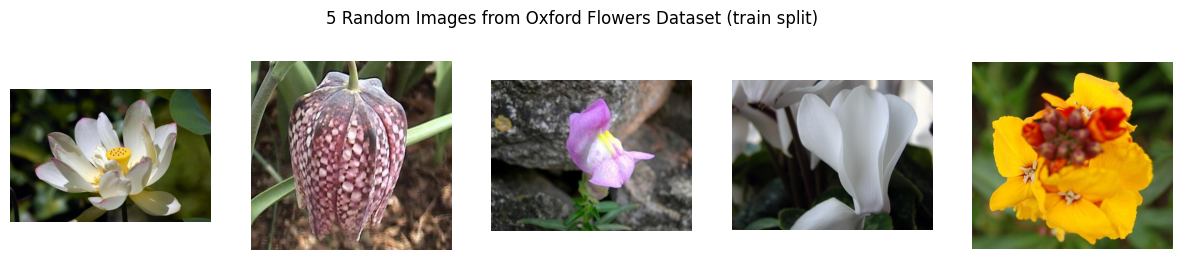

In [13]:
# import matplotlib.pyplot as plt
# import random

random.seed(42)

# Choose 5 random indices from the training split
random_indices = random.sample(range(len(dataset["train"])), 5)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(random_indices):
    image = dataset["train"][idx]["image"]
    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.axis("off")
plt.suptitle("5 Random Images from Oxford Flowers Dataset (train split)")
plt.show()


In [14]:
from torchvision import transforms
from torch.utils.data import DataLoader

# определяем трансформации изображения (например, используя torchvision)
transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(),
    # transforms.ToTensor(),
    # transforms.Lambda(lambda t: (t * 2) - 1)
    transforms.Resize(256),                    # Изменяем размер (короткая сторона = 256)
    transforms.CenterCrop(256),                # Обрезаем до квадрата 256x256
    transforms.ToTensor(),                     # Конвертируем в тензор [0, 1]
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Нормализуем в [-1, 1] для RGB
])

# определяем функцию
def transforms(examples):
    examples["pixel_values"] = [
        # transform(image.convert("L")) for image in examples["image"]
        transform(image.convert("RGB")) for image in examples["image"]
    ]
    del examples["image"]

    return examples

transformed_dataset = dataset.with_transform(transforms).remove_columns("label")

# создаем dataloader
dataloader = DataLoader(
    transformed_dataset["train"], batch_size=batch_size, shuffle=True
)

In [15]:
batch = next(iter(dataloader))
print(batch.keys())

dict_keys(['pixel_values'])


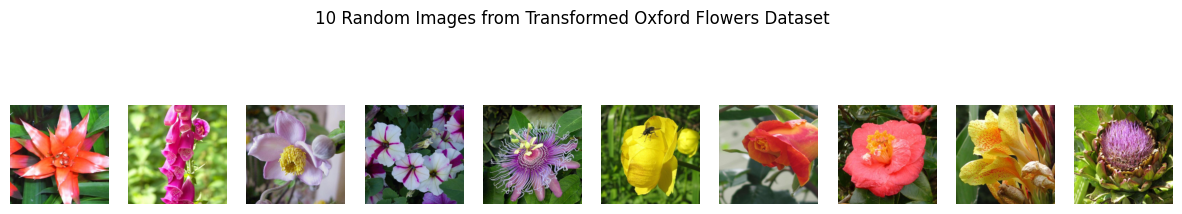

In [16]:
# Get a random batch of 10 images from the dataloader
images = []
count = 0
for batch in dataloader:
    for img in batch["pixel_values"]:
        images.append(img)
        count += 1
        if count == 10:
            break
    if count == 10:
        break

# Convert tensors to numpy and move channels to last dimension
images_np = [img.permute(1, 2, 0).cpu().numpy() for img in images]

# Undo normalization to [0,1] for visualization
images_np = [((img * 0.5) + 0.5).clip(0, 1) for img in images_np]

plt.figure(figsize=(15, 3))
for i, img in enumerate(images_np):
    plt.subplot(1, 10, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("10 Random Images from Transformed Oxford Flowers Dataset")
plt.show()


#### Функция потерь p_losses

In [20]:
def p_losses(denoise_model, x_start, t, noise=None, loss_type="l1"):
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = denoise_model(x_noisy, t)

    if loss_type == 'l1':
        loss = F.l1_loss(noise, predicted_noise)
    elif loss_type == 'l2':
        loss = F.mse_loss(noise, predicted_noise)
    elif loss_type == "huber":
        loss = F.smooth_l1_loss(noise, predicted_noise)
    else:
        raise NotImplementedError()

    return loss

##### alphas, betas, extract, timesteps

In [21]:
timesteps = 200

# определяем beta schedule
betas = cosine_beta_schedule(timesteps=timesteps)
#betas = linear_beta_schedule(timesteps=timesteps)
#betas = quadratic_beta_schedule(timesteps=timesteps)
#betas = sigmoid_beta_schedule(timesteps=timesteps)
# определяем альфа
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# вычисления для диффузии q(x_t | x_{t-1}) и других
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# вычисления для постериорного q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

#### Сэмплирование

In [ ]:
@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # В статье "Equation 11"
    # Используем нашу модель (предиктор шума) чтобы предсказать среднее
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        # Алгоритм 2 - 4-ая строка:
        return model_mean + torch.sqrt(posterior_variance_t) * noise

# Алгоритм 2, но сохраняем изображения:
@torch.no_grad()
def p_sample_loop(model, shape):
    device = next(model.parameters()).device

    b = shape[0]
    # начинаем с чистого шума (для каждого примера в батче)
    img = torch.randn(shape, device=device)
    imgs = []

    for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
        img = p_sample(model, img, torch.full((b,), i, device=device, dtype=torch.long), i)
        imgs.append(img.cpu().numpy())
    return imgs

@torch.no_grad()
def sample(model, image_size, batch_size=16, channels=3):
    return p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))

#### Обучение

##### Периодические сохранения и сэмплирование

In [ ]:
from pathlib import Path

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

results_folder = Path("./results")
results_folder.mkdir(exist_ok = True)
save_and_sample_every = 1000

##### GC

In [ ]:
import gc

# Удаляем старую модель, если она существует
if 'model' in globals():
    del model
    print("Старая модель удалена из памяти")

# Удаляем VAE, если он загружен (освобождаем ~335MB)
if 'vae' in globals():
    del vae
    print("VAE удален из памяти")

# Очищаем кэш CUDA
torch.cuda.empty_cache()
gc.collect()

# Проверяем использование памяти
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    
    print(f"\n=== Состояние GPU памяти ===")
    print(f"Всего: {total:.2f} GB")
    print(f"Занято: {allocated:.2f} GB")
    print(f"Зарезервировано: {reserved:.2f} GB")
    print(f"Свободно: {total - allocated:.2f} GB")
    print("=" * 30)


=== Состояние GPU памяти ===
Всего: 9.77 GB
Занято: 0.00 GB
Зарезервировано: 0.00 GB
Свободно: 9.77 GB


##### Создаем модель и оптимизатор

In [ ]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Unet(
    # dim - это базовое число каналов в UNet, НЕ размер изображения!
    dim=48,  # УМЕНЬШЕНО с 64 для экономии памяти
    channels=channels,
    dim_mults=(1, 2, 3),  # УМЕНЬШЕНО с (1, 2, 4) - каналы: [32, 48, 96, 144] вместо [42, 64, 128, 256]
    use_gradient_checkpointing=True  # ВКЛЮЧЕНО для экономии 40-60% памяти активаций
)
model.to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

# Вывод информации о модели 
total_params = sum(p.numel() for p in model.parameters())
model_size_mb = total_params * 4 / 1024**2

print(f"Всего параметров: {total_params:,}")
print(f"Размер модели: ~{model_size_mb:.1f} МБ (float32)")
print(f"Каналы: {[32, 48, 96, 144]}")
print(f"  - Модель: ~{model_size_mb:.1f} МБ")
print(f"  - Batch данные: ~{batch_size * 3 * 256 * 256 * 4 / 1024**2:.0f} МБ")


Attention heads: 4 (using memory-efficient scaled_dot_product_attention)
Всего параметров: 6,085,875
Размер модели: ~23.2 МБ (float32)
Каналы: [32, 48, 96, 144]
  - Модель: ~23.2 МБ
  - Batch данные: ~6 МБ


##### Цикл обучения

In [ ]:
from torchvision.utils import save_image

epochs = 5

for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()

        batch_size = batch["pixel_values"].shape[0]
        batch = batch["pixel_values"].to(device)

        # Algorithm 1 line 3: sample t uniformally for every example in the batch
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()

        loss = p_losses(model, batch, t, loss_type="huber")

        if step % 100 == 0:
            print("Loss:", loss.item())

        loss.backward()
        optimizer.step()

        # save generated images
        if step != 0 and step % save_and_sample_every == 0:
            milestone = step // save_and_sample_every
            batches = num_to_groups(4, batch_size)
            all_images_list = list(
                map(
                    lambda n: sample(model, image_size=image_size, batch_size=n, channels=channels), 
                    batches
                )
            )
            all_images = torch.cat(all_images_list, dim=0)
            all_images = (all_images + 1) * 0.5
            save_image(all_images, str(results_folder / f'sample-{milestone}.png'), nrow = 6)

---

### [3 балла] Реализация обучения модели latent diffusion

Напоминание про реализацию модели: [Latent Diffusion](https://nn.labml.ai/diffusion/stable_diffusion/latent_diffusion.html)

Для того чтобы из кода обучения Diffusion получить обучение Latent Diffusion, вам нужно добавить VQ-VAE и обрабатывать изображения с помощью `vae.encode`. Далее полученные latent, подаются в стандартный пайплайн обучения. Учтите, что latent имеет меньшую размерность и вам может понадобиться уменьшить число слоев в архитектуре UNet.

В качестве модели VQ-VAE вы можете воспользоваться предобученным VQ-VAE от Stable diffusion.

**Ожидаемый результат.** В качестве результатов модели от вас требуется предоставить визуализации генераций, полученных от вашей модели, и код обучения модели.

In [ ]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


In [ ]:
# your code

### [2 балла] Анализ влияния scheduler на качество генерации

 На качество генерации может влиять используемый scheduler и число шагов, поэтому в этой части домашнего задания, вам предлагается происследовать визуально как scheduler и число шагов влияют на качество генерации. Вам предлагается рассмотреть качество генерации на 10 различных числах шагов,  используя различные scheduler.


 В качестве scheduler предлагается стандартный DDPM, DDIM, DPMSolver (другие scheduler не воспрещаются). Обратите внимание, что DDIM и DPMSolver являются детерминированными scheduler, а значит, результат у них должен получаться одиннаковый.

 **Ожидаемый результат.** В качестве результатов в этом пункте от вас требуется предоставить визуализации картинок в различных вариации числа шагов и scheduler и сделать выводы, какие параметры лучше использовать. Вы можете выполнить эту часть, не используя обученную выше модель, а используя стандартные pipeline StableDiffusion

In [ ]:
# your code + visualizations

### Дополнительное задание [дополнительный 1 балл]. Модификации conditional guidance*
*Дополнительный балл не умножается на коэффициент домашнего задания*

---

Далее вам предлагается реализовать conditional guidance на этом датасете. Как уже упоминалось на лекции механизм conditional guidance позволяет вам генерировать изображения с выбранными вами условиями (картинки определенных цветков, например). На семинаре 2 был показан участок кода, который реализовал условную генерацию, однако для этого вам нужно добавить прокидывание условия в UNet и чуть поменять процесс условной генерации. При реализации вы можете опираться адаптировать следующую [реализацию](https://github.com/TeaPearce/Conditional_Diffusion_MNIST).

**Ожидаемый результат.** В качестве результатов модели, от вас требуется предоставить визуализации генераций, полученных от вашей модели, и код обучения модели.
